In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

In [4]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving heart.csv to heart.csv
User uploaded file "heart.csv" with length 38114 bytes


In [5]:
df = pd.read_csv("heart.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Train acc: 1.000 | Test acc: 0.985


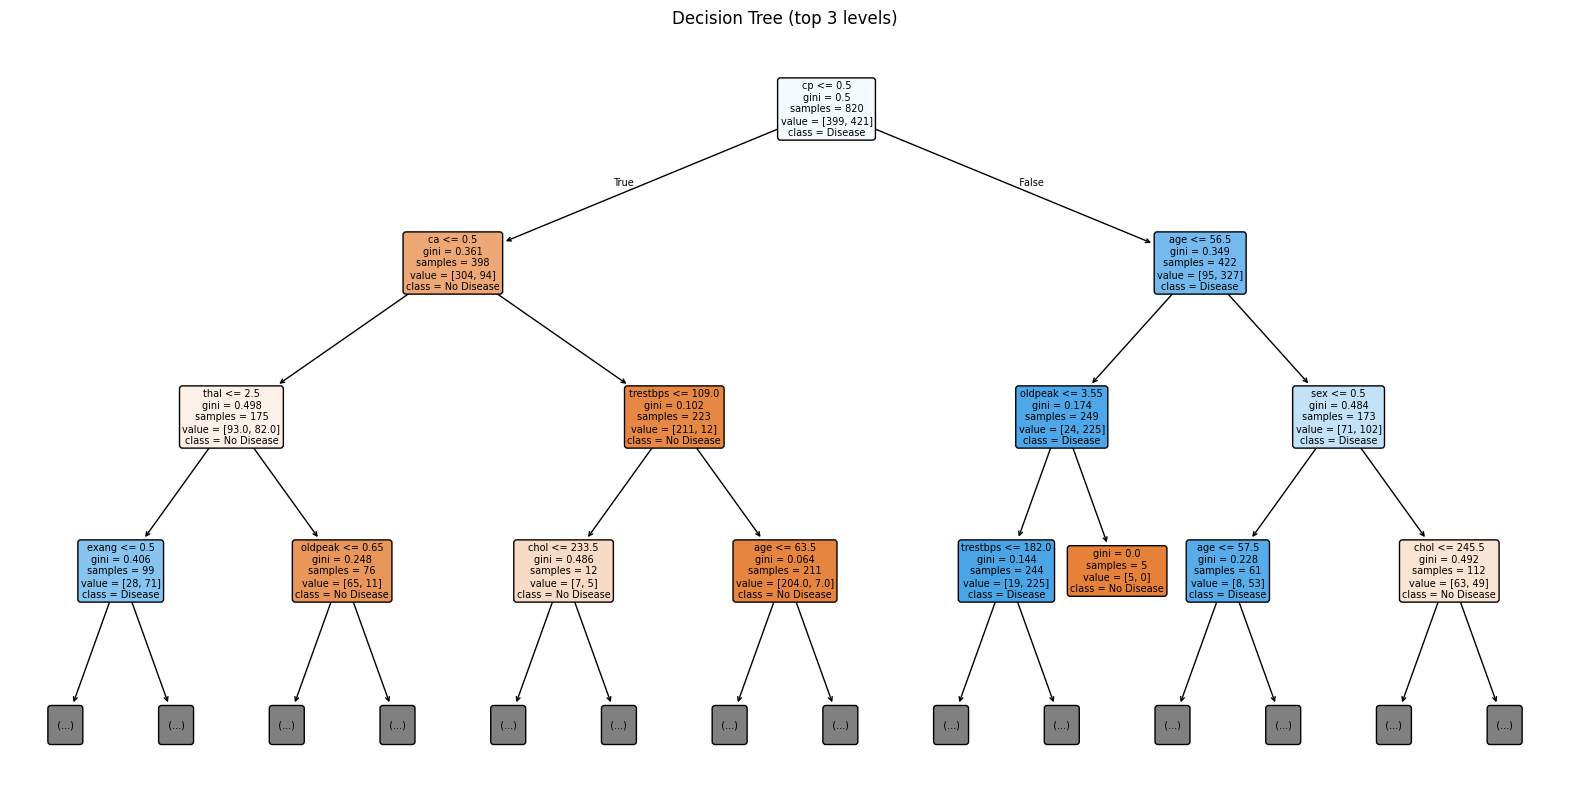

In [7]:
dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)

train_acc_full = accuracy_score(y_train, dt_full.predict(X_train))
test_acc_full = accuracy_score(y_test, dt_full.predict(X_test))
print(f"Train acc: {train_acc_full:.3f} | Test acc: {test_acc_full:.3f}")

plt.figure(figsize=(20,10))
plot_tree(dt_full, feature_names=X.columns, class_names=["No Disease","Disease"],
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title("Decision Tree (top 3 levels)")
plt.show()

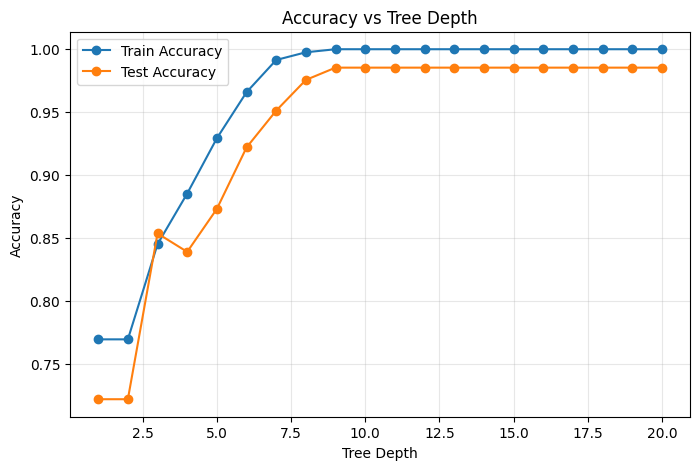

Best depth: 9


In [8]:
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
print("Best depth:", best_depth)

Pruned Tree (depth=9) -> Train: 1.000 | Test: 0.985


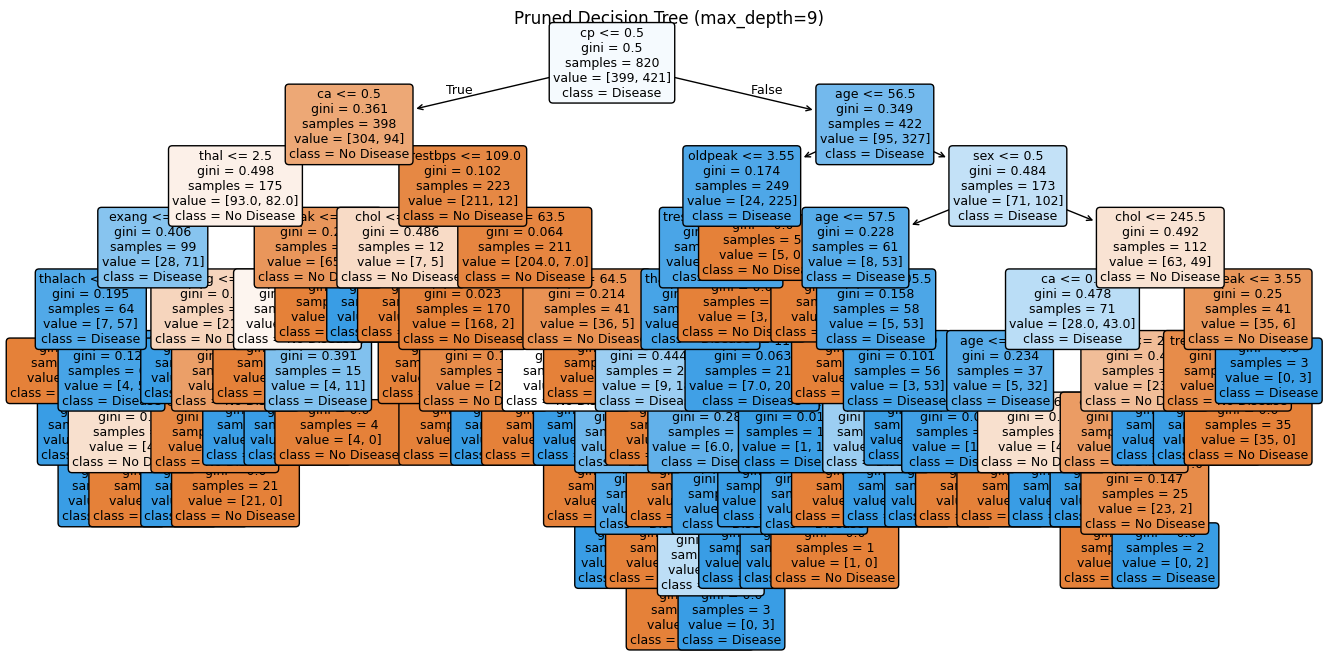

In [9]:
dt_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_pruned.fit(X_train, y_train)

train_acc_pruned = accuracy_score(y_train, dt_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, dt_pruned.predict(X_test))
print(f"Pruned Tree (depth={best_depth}) -> Train: {train_acc_pruned:.3f} | Test: {test_acc_pruned:.3f}")

plt.figure(figsize=(16,8))
plot_tree(dt_pruned, feature_names=X.columns, class_names=["No Disease","Disease"],
          filled=True, rounded=True, fontsize=9)
plt.title(f"Pruned Decision Tree (max_depth={best_depth})")
plt.show()

In [10]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest -> Train: {train_acc_rf:.3f} | Test: {test_acc_rf:.3f}")

print("\nClassification Report:\n", classification_report(y_test, rf.predict(X_test)))

comparison = pd.DataFrame({
    "Model": ["Decision Tree (full)", f"Decision Tree (depth={best_depth})", "Random Forest"],
    "Train Accuracy": [train_acc_full, train_acc_pruned, train_acc_rf],
    "Test Accuracy": [test_acc_full, test_acc_pruned, test_acc_rf],
})
comparison

Random Forest -> Train: 1.000 | Test: 1.000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



,Model,Train Accuracy,Test Accuracy
0,Decision Tree (full),1.0,0.985366
1,Decision Tree (depth=9),1.0,0.985366
2,Random Forest,1.0,1.000000


cp          0.144796
thalach     0.118097
ca          0.110965
oldpeak     0.105590
thal        0.101825
age         0.091826
chol        0.076579
exang       0.074189
trestbps    0.071178
slope       0.045234
sex         0.029885
restecg     0.019166
fbs         0.010670
dtype: float64


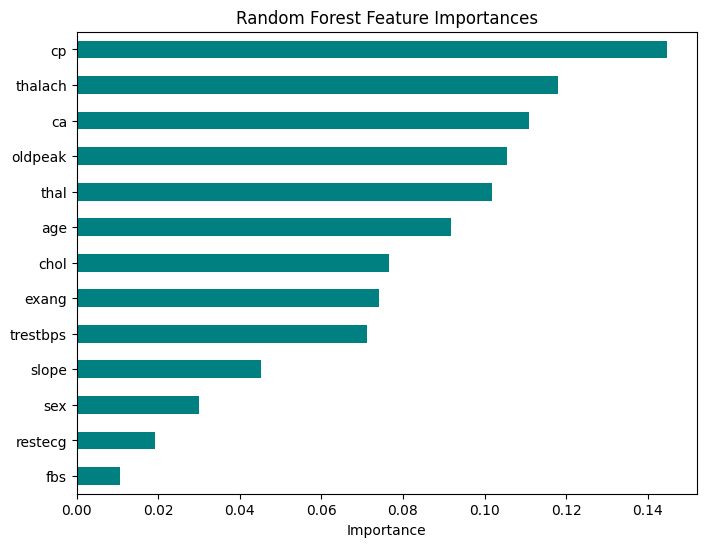

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind="barh", color="teal")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [12]:
cv_scores_dt = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE), X, y, cv=5)
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X, y, cv=5)

print(f"Decision Tree CV mean: {cv_scores_dt.mean():.3f}, scores: {np.round(cv_scores_dt,3)}")
print(f"Random Forest CV mean: {cv_scores_rf.mean():.3f}, scores: {np.round(cv_scores_rf,3)}")

Decision Tree CV mean: 0.998, scores: [1.   1.   1.   0.99 1.  ]
Random Forest CV mean: 0.997, scores: [1.    1.    1.    1.    0.985]


In [13]:
print(df.columns.tolist())
df.head()

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [14]:
print("Total rows:", df.shape[0])
print("Duplicate rows:", df.duplicated().sum())

Total rows: 1025
Duplicate rows: 723


In [15]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)


Shape after dropping duplicates: (302, 14)


In [16]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

Train acc: 1.000 | Test acc: 0.803


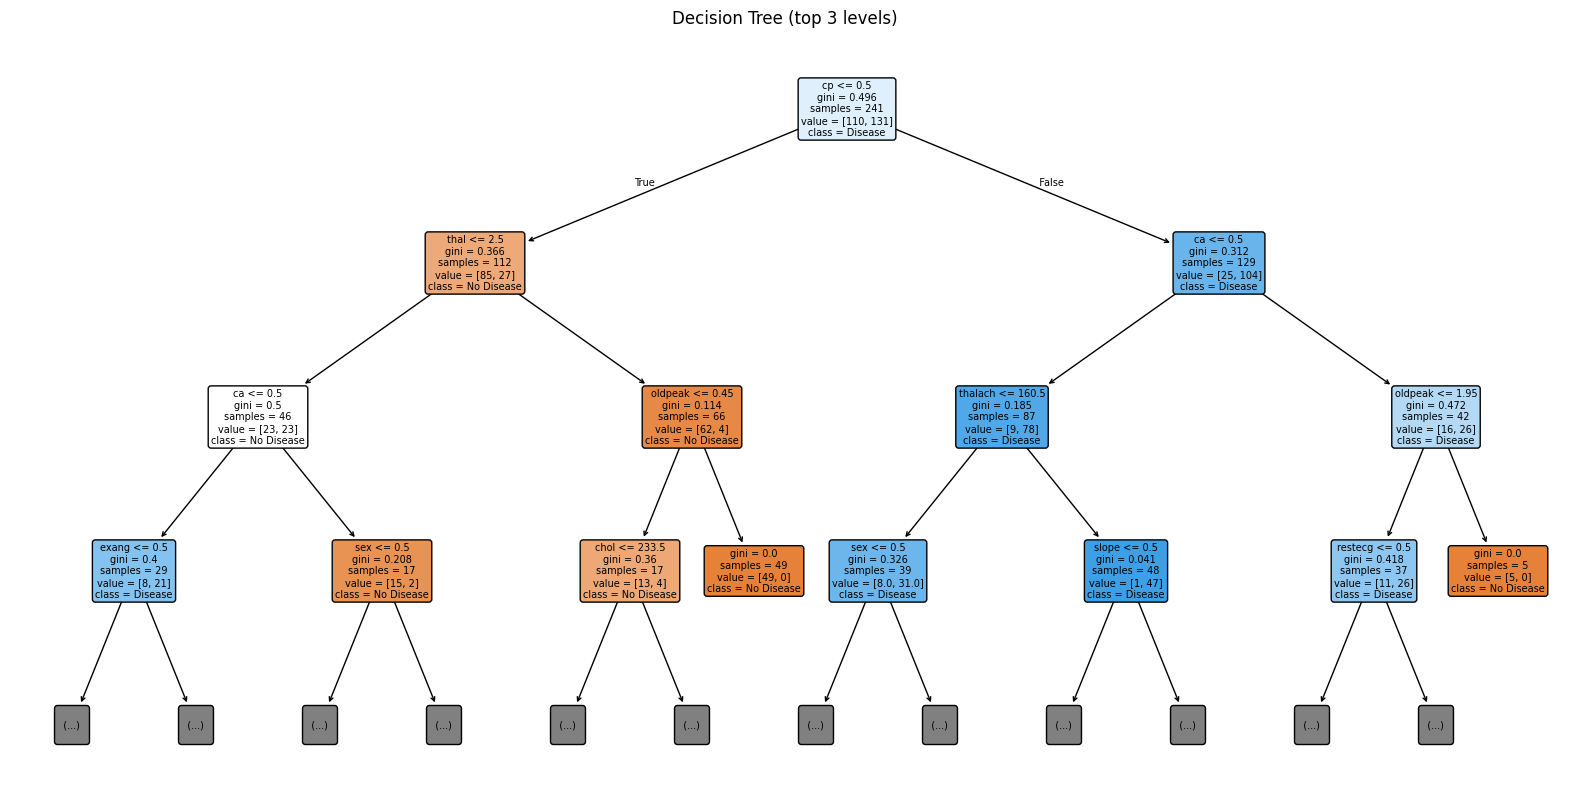

In [17]:
dt_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)

train_acc_full = accuracy_score(y_train, dt_full.predict(X_train))
test_acc_full = accuracy_score(y_test, dt_full.predict(X_test))
print(f"Train acc: {train_acc_full:.3f} | Test acc: {test_acc_full:.3f}")

plt.figure(figsize=(20,10))
plot_tree(dt_full, feature_names=X.columns, class_names=["No Disease","Disease"],
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title("Decision Tree (top 3 levels)")
plt.show()

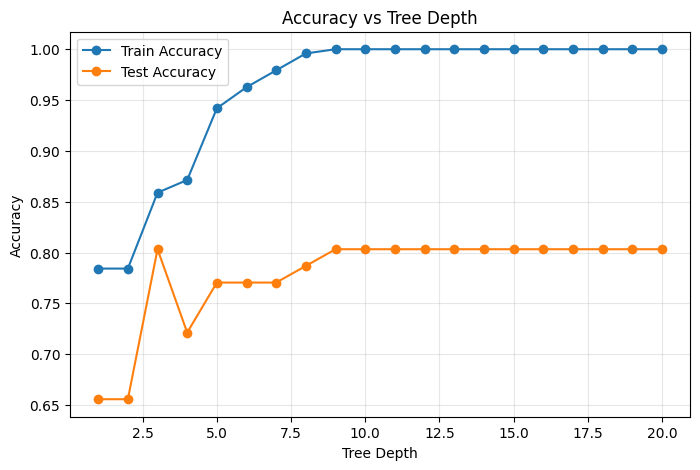

Best depth: 3


In [18]:
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Tree Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
print("Best depth:", best_depth)

Pruned Tree (depth=3) -> Train: 0.859 | Test: 0.803


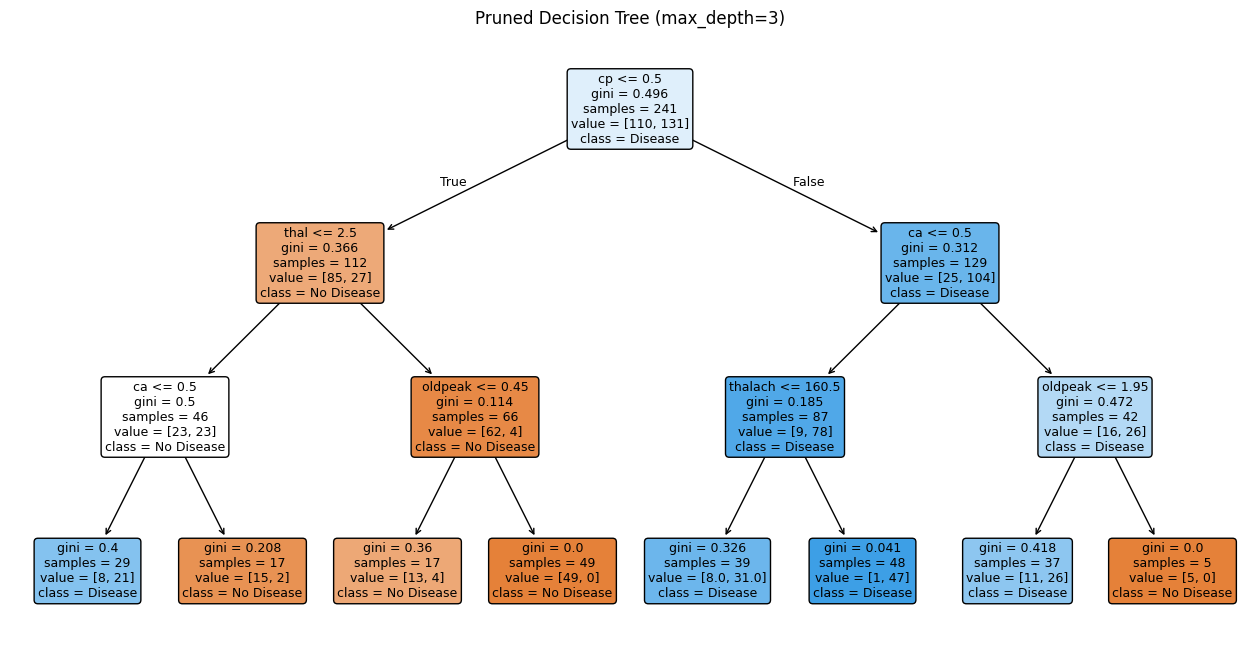

In [19]:
dt_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_pruned.fit(X_train, y_train)

train_acc_pruned = accuracy_score(y_train, dt_pruned.predict(X_train))
test_acc_pruned = accuracy_score(y_test, dt_pruned.predict(X_test))
print(f"Pruned Tree (depth={best_depth}) -> Train: {train_acc_pruned:.3f} | Test: {test_acc_pruned:.3f}")

plt.figure(figsize=(16,8))
plot_tree(dt_pruned, feature_names=X.columns, class_names=["No Disease","Disease"],
          filled=True, rounded=True, fontsize=9)
plt.title(f"Pruned Decision Tree (max_depth={best_depth})")
plt.show()

In [20]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest -> Train: {train_acc_rf:.3f} | Test: {test_acc_rf:.3f}")

print("\nClassification Report:\n", classification_report(y_test, rf.predict(X_test)))

comparison = pd.DataFrame({
    "Model": ["Decision Tree (full)", f"Decision Tree (depth={best_depth})", "Random Forest"],
    "Train Accuracy": [train_acc_full, train_acc_pruned, train_acc_rf],
    "Test Accuracy": [test_acc_full, test_acc_pruned, test_acc_rf],
})
comparison

Random Forest -> Train: 1.000 | Test: 0.754

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



,Model,Train Accuracy,Test Accuracy
0,Decision Tree (full),1.000000,0.803279
1,Decision Tree (depth=3),0.858921,0.803279
2,Random Forest,1.000000,0.754098


cp          0.166320
thalach     0.128711
ca          0.109447
thal        0.099737
oldpeak     0.093087
age         0.086755
exang       0.072760
chol        0.070916
trestbps    0.070149
sex         0.037530
slope       0.031531
restecg     0.023953
fbs         0.009103
dtype: float64


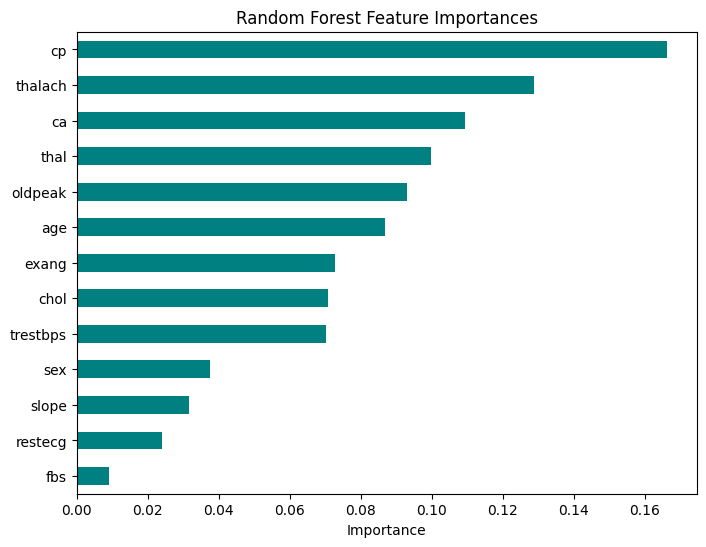

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,6))
importances.sort_values().plot(kind="barh", color="teal")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [22]:
cv_scores_dt = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE), X, y, cv=5)
cv_scores_rf = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X, y, cv=5)

print(f"Decision Tree CV mean: {cv_scores_dt.mean():.3f}, scores: {np.round(cv_scores_dt,3)}")
print(f"Random Forest CV mean: {cv_scores_rf.mean():.3f}, scores: {np.round(cv_scores_rf,3)}")

Decision Tree CV mean: 0.795, scores: [0.803 0.82  0.9   0.683 0.767]
Random Forest CV mean: 0.821, scores: [0.869 0.82  0.883 0.767 0.767]
